In [942]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Understanding Data

In [943]:
df = pd.read_csv("../data/online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [944]:
print(f'The data has {df.shape[0]} rows and {df.shape[1]} columns')

The data has 541909 rows and 8 columns


In [945]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [946]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [947]:
df.duplicated().sum()

np.int64(5268)

In [948]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [949]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [950]:
# Cancelled invoices usually have an InvoiceNo that starts with "C".
df['IsCancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')
df['IsCancelled'].sum()

np.int64(9288)

In [951]:
# False indicates normal purchase and True indicates cancellation
df['IsCancelled'].value_counts()

IsCancelled
False    532621
True       9288
Name: count, dtype: int64

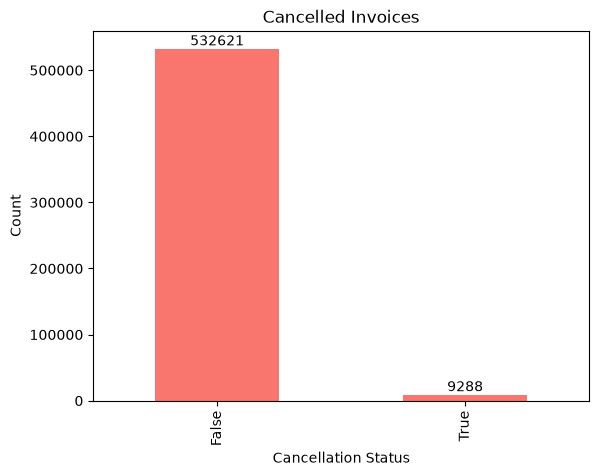

In [952]:
ax = df['IsCancelled'].value_counts().plot(kind='bar', color='#F8766D')
ax.bar_label(ax.containers[0])
ax.set_xlabel('Cancellation Status')
ax.set_ylabel('Count')
ax.set_title('Cancelled Invoices')
plt.savefig('../images/cancelled_invoices.png', bbox_inches='tight')
plt.show()

**Insight**
- The data has 9288 cancelled invoices

## Data Cleaning

In [953]:
cleaned_df = df.copy()
cleaned_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False


In [954]:
# Dropped null CustomerID row because CLV is calculated at the customer level and with null values i cannot move further.
cleaned_df['CustomerID'].isnull().sum()
cleaned_df = df.dropna(subset=['CustomerID'])
cleaned_df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
IsCancelled    0
dtype: int64

In [955]:
# Dropped IsCancelled column because it is not useful in CLV prediction
cleaned_df.drop(columns=['IsCancelled'], inplace=True)
cleaned_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [956]:
# Removed rows with negative quantity (cancellations)
cleaned_df = cleaned_df[~cleaned_df['InvoiceNo'].astype(str).str.startswith('C')]

In [957]:
# Removed rows with zero or negative quantity
cleaned_df = cleaned_df[cleaned_df['Quantity'] > 0]
cleaned_df = cleaned_df[cleaned_df['UnitPrice'] > 0] 

In [958]:
# Converted 'InvoiceDate' to datetime
cleaned_df['InvoiceDate'] = pd.to_datetime(cleaned_df['InvoiceDate'])

In [959]:
# Created new feature TotalPrice
cleaned_df['TotalPrice'] = cleaned_df['Quantity'] * cleaned_df['UnitPrice']

In [960]:
# Removed rows with zero or negative quantity
cleaned_df = cleaned_df[cleaned_df['TotalPrice'] > 0]

In [961]:
# Dropped duplicates because keeping them would double-count some transactions.
cleaned_df = cleaned_df.drop_duplicates()

In [962]:
cleaned_df.duplicated().sum()

np.int64(0)

In [963]:
cleaned_df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.0 MB


In [964]:
cleaned_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


## Exploratory Data Analysis

In [965]:
cleaned_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [966]:
cleaned_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='str')

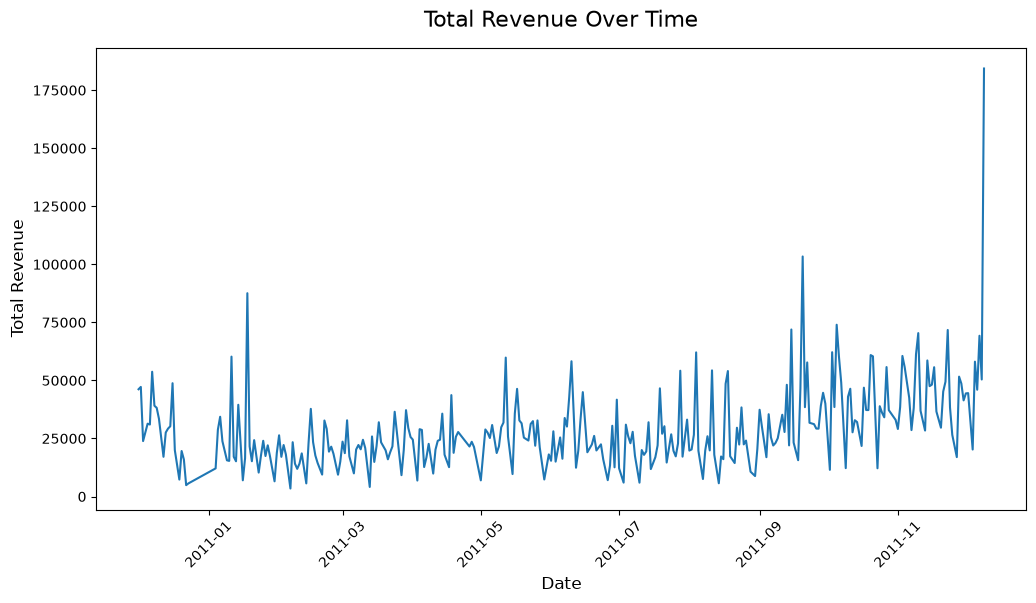

In [967]:
# How has revenue changed over time?
df_grouped = cleaned_df.groupby(cleaned_df['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, x='InvoiceDate', y='TotalPrice')
plt.title('Total Revenue Over Time', fontsize=16, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.savefig('../images/total_revenue_over_time.png', bbox_inches='tight')
plt.show()

**Insight**
- Revenue remains relatively stable until getting a massive spike

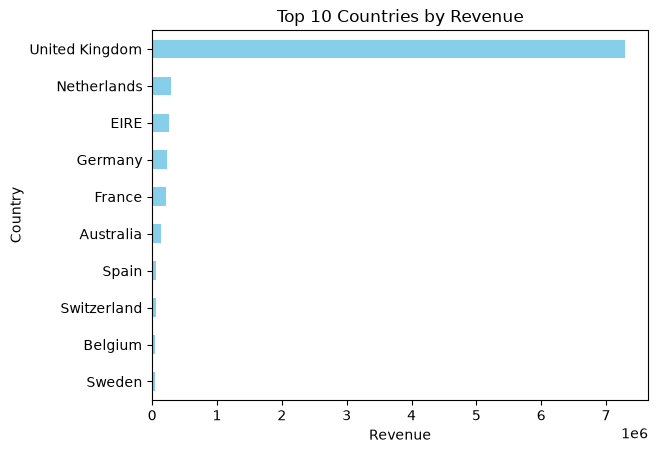

In [968]:
# Which top 10 countries generate the most revenue?
top_countries = cleaned_df.groupby('Country')['TotalPrice'].sum().nlargest(10)
top_countries.sort_values(ascending=True, inplace=True)
top_countries.plot(kind='barh', color='skyblue')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.title('Top 10 Countries by Revenue')
plt.savefig('../images/top_10_revenue_countries.png', bbox_inches='tight')
plt.show()

**Insight**
- United Kingdom generates the highest revenue

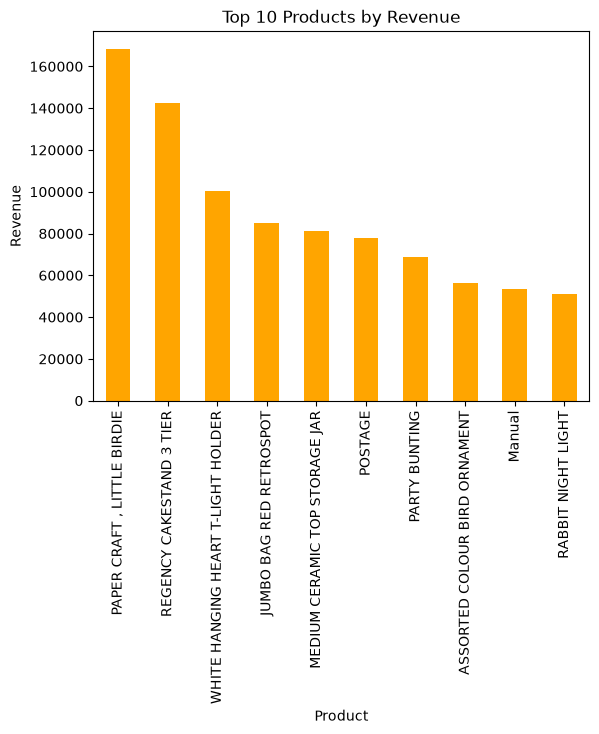

In [969]:
# Which products generate the highest revenue?
top_products = cleaned_df.groupby('Description')['TotalPrice'].sum().nlargest(10)
top_products.sort_values(ascending=False, inplace=True)
top_products.plot(kind='bar', color='orange')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.title('Top 10 Products by Revenue')
plt.savefig('../images/top_products_by_revenue.png', bbox_inches='tight')
plt.show()

**Insight**
The paper craft little birdie generates the highest revenue.

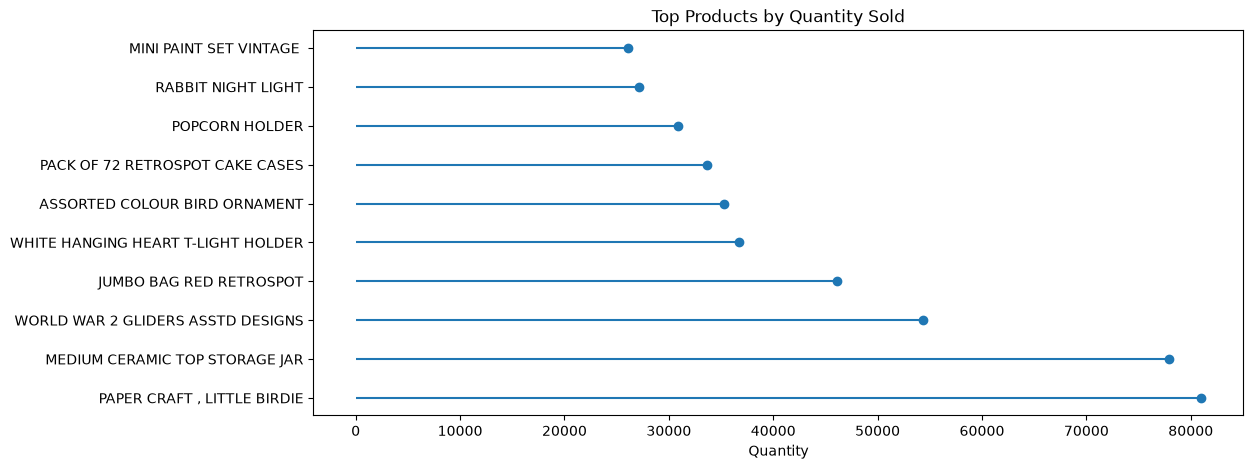

In [970]:
# Which products are sold the most (by quantity)?
top_quantity = cleaned_df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5)) 
plt.hlines(y=top_quantity.index, xmin=0, xmax=top_quantity.values) 
plt.plot(top_quantity.values, top_quantity.index, 'o') 
plt.title('Top Products by Quantity Sold') 
plt.xlabel('Quantity') 
plt.savefig('../images/top_products_by_quantity_sold.png', bbox_inches='tight')
plt.show()

**Insight**
- PAPER CRAFT , LITTLE BIRDIE and MEDIUM CERAMIC TOP STORAGE JAR are sold the most.

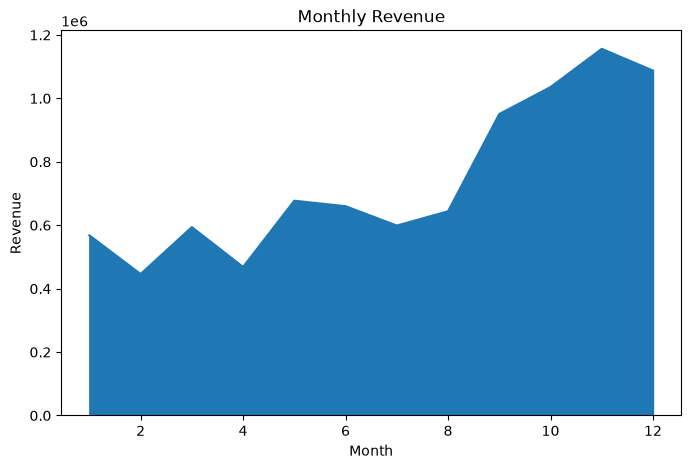

In [971]:
# Which month has the highest revenue?
cleaned_df['Month'] = cleaned_df['InvoiceDate'].dt.month 
monthly_sales = cleaned_df.groupby('Month')['TotalPrice'].sum() 
plt.figure(figsize=(8,5)) 
monthly_sales.plot(kind='area') 
plt.title('Monthly Revenue') 
plt.xlabel('Month') 
plt.ylabel('Revenue') 
plt.savefig('../images/monthly_revenue.png', bbox_inches='tight')
plt.show()

**Insight**
- Overall monthly revenue steadily increases before peaking in November.

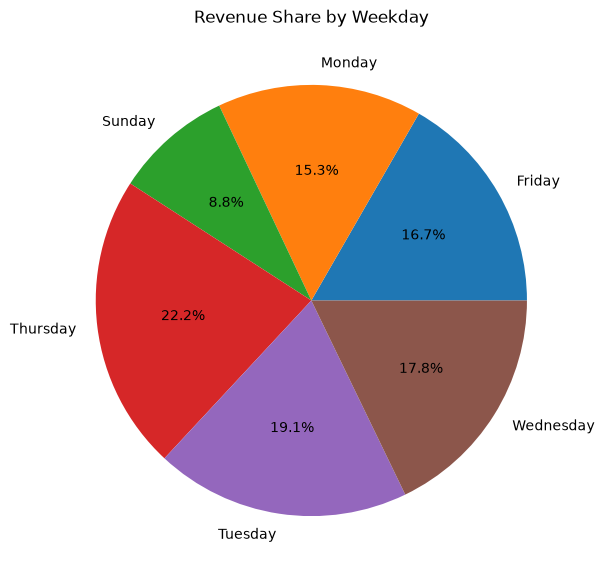

In [972]:
# Which weekday performs best?
cleaned_df['Weekday'] = cleaned_df['InvoiceDate'].dt.day_name()
weekday_sales = cleaned_df.groupby('Weekday')['TotalPrice'].sum()
plt.figure(figsize=(7,7))
weekday_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue Share by Weekday')
plt.savefig('../images/revenue_share_by_weekday.png', bbox_inches='tight')
plt.show()


**Insight**
- Thursday and Tuesday generate the largest shares of revenue

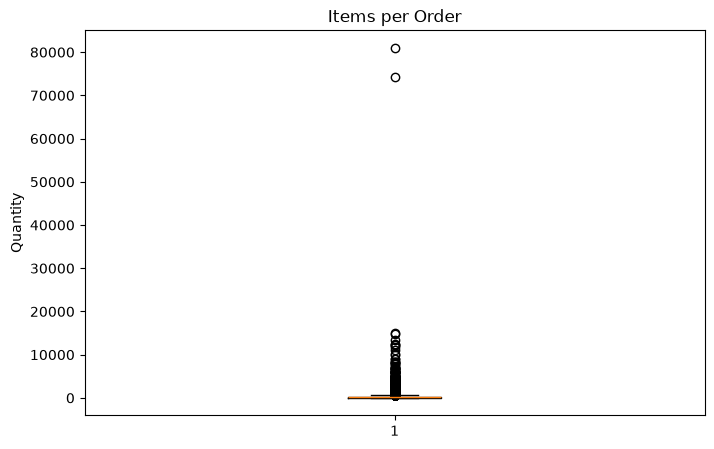

In [973]:
# How many products are usually bought in an order?
items_per_order = cleaned_df.groupby('InvoiceNo')['Quantity'].sum() 
plt.figure(figsize=(8,5)) 
plt.boxplot(items_per_order) 
plt.title('Items per Order') 
plt.ylabel('Quantity') 
plt.savefig('../images/items_per_order.png', bbox_inches='tight')
plt.show()

**Insights**
- Order quantities are usually low but feature extreme outliers.

In [974]:
items_per_order.describe()

count    18532.000000
mean       278.005720
std        972.389641
min          1.000000
25%         74.000000
50%        154.000000
75%        290.000000
max      80995.000000
Name: Quantity, dtype: float64

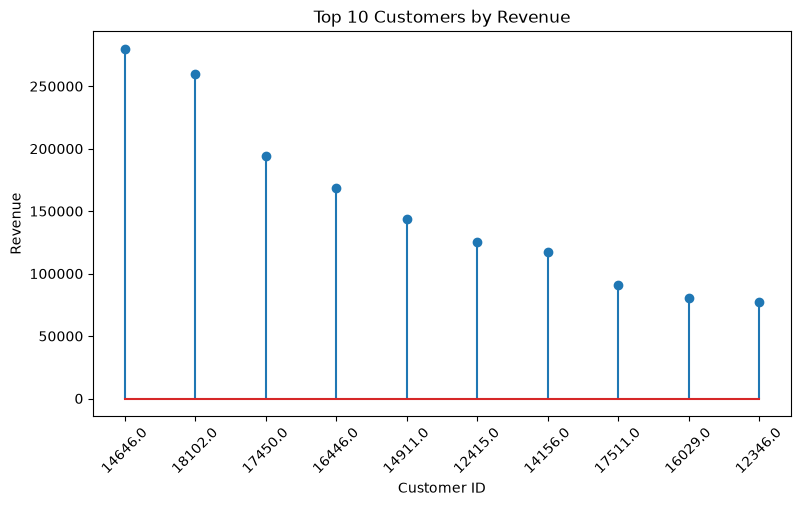

In [975]:
# Who are the top customers by revenue?
top_customers = cleaned_df.groupby('CustomerID')['TotalPrice'].sum().nlargest(10)
plt.figure(figsize=(9,5)) 
markerline, stemlines, baseline = plt.stem(top_customers.index.astype(str), top_customers.values) 
plt.title('Top 10 Customers by Revenue') 
plt.xlabel('Customer ID') 
plt.ylabel('Revenue') 
plt.xticks(rotation=45) 
plt.savefig('../images/customers_by_revenue.png', bbox_inches='tight')
plt.show()

**Insight**
- Customer with CustomerID (14646.0) is the top customer 

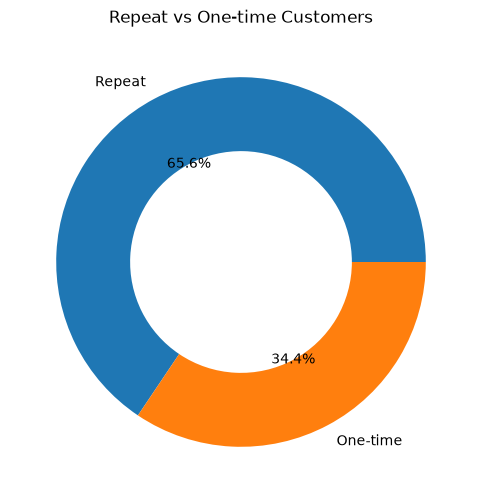

In [976]:
# How many repeat vs one-time customers are there?
orders_per_customer = cleaned_df.groupby('CustomerID')['InvoiceNo'].nunique() 
repeat = (orders_per_customer > 1).sum() 
one_time = (orders_per_customer == 1).sum() 
plt.figure(figsize=(6,6)) 
plt.pie([repeat, one_time], labels=['Repeat', 'One-time'], autopct='%1.1f%%', wedgeprops={'width':0.4}) 
plt.title('Repeat vs One-time Customers') 
plt.savefig('../images/repeat_vs_onetime_customers.png', bbox_inches='tight')
plt.show()

**Insight**
- The data shows 65.6% Repeat customers and 34.4% One time customers.

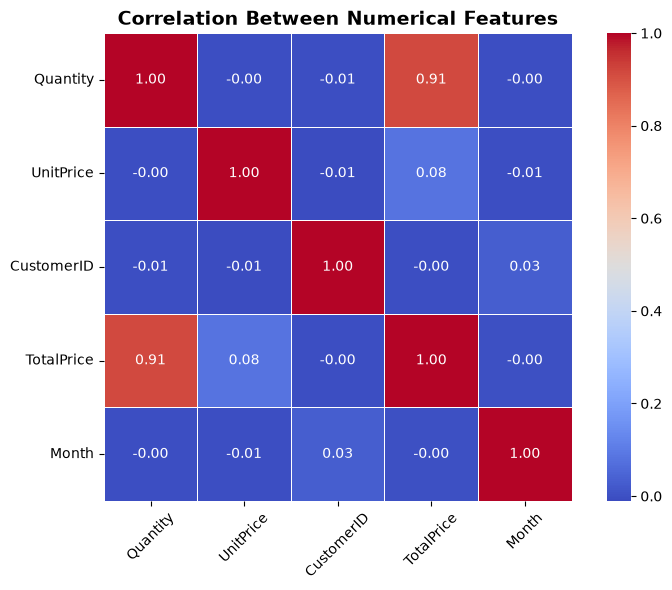

In [977]:
# Which numerical features have the strongest relationship with TotalPrice, and what does that tell us about customer spending?
corr = cleaned_df.corr(numeric_only=True)  
plt.figure(figsize=(8, 6)) 
sns.heatmap( corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True ) 
plt.title('Correlation Between Numerical Features', fontsize=14, weight='bold') 
plt.xticks(rotation=45) 
plt.yticks(rotation=0) 
plt.tight_layout() 
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Insight**
- The plot shows a strong positive correlation of 0.91 between Quantity and TotalPrice, with other features showing near zero correlation to each other.

In [978]:
# Skewness
numerical_columns = cleaned_df.select_dtypes(include='number')
numerical_columns.skew()

Quantity      407.345663
UnitPrice     202.740861
CustomerID      0.030148
TotalPrice    448.521779
Month          -0.440356
dtype: float64

## Feature Engineering
#### Goal is to create new features:
* Recency 
* Frequency 
* Monetary 

In [979]:
cleaned_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Month', 'Weekday'],
      dtype='str')

In [980]:
# Sets current date one day after latest invoice.
current_date = cleaned_df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [981]:
# RFM Calculation
rfm = cleaned_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (current_date - x.max()).days, # current date - most recent purchase date
    'InvoiceNo': 'nunique', # number of unique invoices
    'TotalPrice': 'sum' # sum of money spent
})

In [982]:
# Renamed columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

1. **Recency** -> How many days since the customer’s last purchase
- High recency -> bad (inactive customer)
- Low recency -> good (active customer)

2. **Frequency** -> How many different orders the customer made
- High frequency -> loyal customer (purchases often)
- Low frequency -> one time buyer (purchases not so often)

3. **Monetary** -> Total money spent by the customer
- High monetary -> valuable customer
- Low monetary -> low value customer

In [983]:
# Create time split for last 90 days
split_date = cleaned_df['InvoiceDate'].max() - pd.Timedelta(days=90)
split_date

Timestamp('2011-09-10 12:50:00')

In [984]:
# Create future dataframe for past 90 days to see what we know about the customer
train_df = cleaned_df[cleaned_df['InvoiceDate'] <= split_date]
train_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday


In [985]:
# Create future dataframe for next 90 days to find what we want to predict
future_df = cleaned_df[cleaned_df['InvoiceDate'] > split_date]
future_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Weekday
334054,566225,22384,LUNCH BAG PINK POLKADOT,6,2011-09-11 10:35:00,1.65,16899.0,United Kingdom,9.90,9,Sunday
334055,566225,20725,LUNCH BAG RED RETROSPOT,6,2011-09-11 10:35:00,1.65,16899.0,United Kingdom,9.90,9,Sunday
334056,566225,23169,CLASSIC GLASS COOKIE JAR,3,2011-09-11 10:35:00,4.15,16899.0,United Kingdom,12.45,9,Sunday
334057,566225,84029E,RED WOOLLY HOTTIE WHITE HEART.,3,2011-09-11 10:35:00,4.25,16899.0,United Kingdom,12.75,9,Sunday
334058,566225,21479,WHITE SKULL HOT WATER BOTTLE,3,2011-09-11 10:35:00,4.25,16899.0,United Kingdom,12.75,9,Sunday


In [986]:
# RFM calculation for training data
rfm_train = train_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (split_date - x.max()).days, # How many days before the split date was the customer’s last purchase?
    'InvoiceNo': 'nunique', # How many different orders the customer made before the split date.
    'TotalPrice': 'sum' # Total money spent before the split date.
})

rfm_train.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [987]:
# Calculates money spent by each customer during the next 90 days
clv = future_df.groupby('CustomerID')['TotalPrice'].sum()
clv = clv.reset_index()
clv.columns = ['CustomerID', 'CLV']
clv.head()

,CustomerID,CLV
0,12347.0,1519.14
1,12348.0,310.00
2,12349.0,1757.55
3,12352.0,944.23
4,12356.0,58.35


In [988]:
# Merge Features and Target
final_df = rfm_train.merge(clv, on='CustomerID', how='left')
# Fill customers with no future purchases
final_df['CLV'] = final_df['CLV'].fillna(0)

In [989]:
final_df.head()

,CustomerID,Recency,Frequency,Monetary,CLV
0,12346.0,235,1,77183.60,0.00
1,12347.0,39,5,2790.86,1519.14
2,12348.0,158,3,1487.24,310.00
3,12350.0,219,1,334.40,0.00
4,12352.0,171,5,1561.81,944.23


**Explaination**
- Here, Above i used a time-based split where the last 90 days of transactions were treated as the future period. From all transactions before that period, I created RFM features for each customer. Then I calculated the customer’s actual spending during the next 90 days and used it as the CLV target. This allows the model to learn how past purchasing behavior relates to future customer value

In [990]:
final_df.drop(columns=['CustomerID'], inplace=True)

In [991]:
final_df.head()

,Recency,Frequency,Monetary,CLV
0,235,1,77183.60,0.00
1,39,5,2790.86,1519.14
2,158,3,1487.24,310.00
3,219,1,334.40,0.00
4,171,5,1561.81,944.23


## Final Visualization

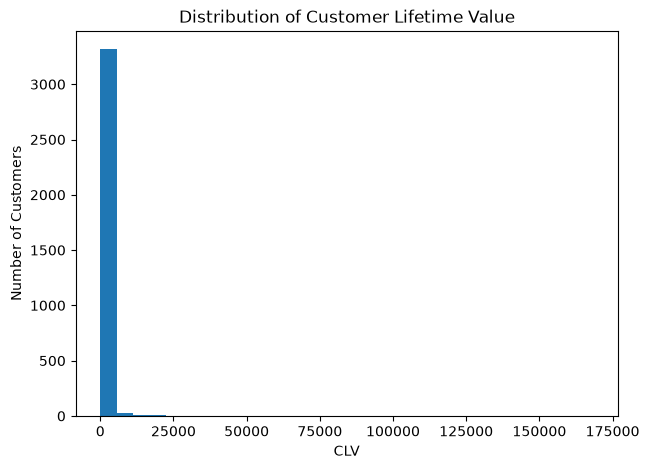

In [992]:
# How is CLV distributed across customers?
plt.figure(figsize=(7,5)) 
plt.hist(final_df['CLV'], bins=30) 
plt.xlabel('CLV') 
plt.ylabel('Number of Customers') 
plt.title('Distribution of Customer Lifetime Value') 
plt.savefig('../images/clv_distribution.png', bbox_inches='tight')
plt.show()

**Insight**
- The customer lifetime value distribution is highly right-skewed, showing that the majority of customers generate low value, leaving few high value outliers.

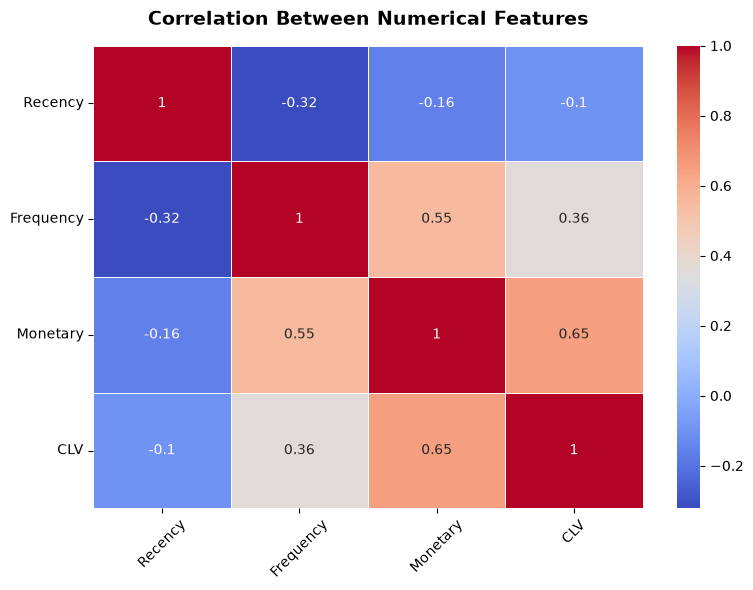

In [993]:
# Correlation Heatmap of RFM
corr = final_df[['Recency', 'Frequency', 'Monetary', 'CLV']].corr() 
plt.figure(figsize=(8, 6)) 
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, linecolor='white') 
plt.title('Correlation Between Numerical Features', fontsize=14, fontweight='bold', pad=15) 
plt.xticks(rotation=45) 
plt.yticks(rotation=0) 
plt.tight_layout() 
plt.savefig('../images/correlation_heatmap2.png', bbox_inches='tight')
plt.show()

**Insight**
- Monetary value and CLV show the strongest positive correlation at 0.65, meaning that higher spending strongly predicts a greater overall customer lifetime value.